# Occupational Map

## Intro

Goal: Use PCA to create an interactive map showing similarities between different occupations to help people explore career opportunities.

dataset source: https://www.onetcenter.org/database.html#all-files

## Libraries

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

## Helper Functions

In [2]:
def missing_values_hist_plot(df, bins):
    '''Returns subplots showing the presence of missing values both across occupations (subplot 1) and within occupations 
    (subplot 2)'''
    
    fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))
    for i in range(0, 2):
        plt.subplot(1, 2, i+1)
        sns.histplot(df.isna().sum(axis = i), bins = bins)
        
    # plot #1
    ax[0].set_title('Distribution of Missing\nMetrics per Occupation')
    ax[0].set_xlabel('Number of Missing Metrics')
    ax[0].set_ylabel('Frequency')
    
    # plot #2
    ax[1].set_title('Distribution of Missing\nOccupations per Metric')
    ax[1].set_xlabel('Number of Missing Occupations')
    ax[1].set_ylabel('Frequency')

    plt.subplots_adjust(wspace = 0.4)
    plt.show()

In [3]:
def drop_missing_values(df, axis, min_missing_values):
    '''drops either rows (axis = 0) or columns (axis = 1) of df based on a threshold minimum number of missing values, 
    returns new df'''
    
    return df.dropna(axis = axis, thresh = df.shape[1 if axis == 0 else 0] - min_missing_values)

## EDA

Our dataset is comprised of many tables, each pertaining to a different measure of components that make up each occupation. Lets just start by looking at one of these files:

In [4]:
knowledge = pd.read_excel('db_28_2_excel/Knowledge.xlsx')

In [5]:
knowledge.head()

,O*NET-SOC Code,Title,Element ID,Element Name,Scale ID,Scale Name,Data Value,N,Standard Error,Lower CI Bound,Upper CI Bound,Recommend Suppress,Not Relevant,Date,Domain Source
0,11-1011.00,Chief Executives,2.C.1.a,Administration and Management,IM,Importance,4.78,28.0,0.1102,4.5564,5.0000,N,NaN,08/2023,Incumbent
1,11-1011.00,Chief Executives,2.C.1.a,Administration and Management,LV,Level,6.50,28.0,0.2130,6.0666,6.9409,N,N,08/2023,Incumbent
2,11-1011.00,Chief Executives,2.C.1.b,Administrative,IM,Importance,2.42,28.0,0.4651,1.4662,3.3749,N,NaN,08/2023,Incumbent
3,11-1011.00,Chief Executives,2.C.1.b,Administrative,LV,Level,2.69,28.0,0.8678,0.9078,4.4690,N,N,08/2023,Incumbent
4,11-1011.00,Chief Executives,2.C.1.c,Economics and Accounting,IM,Importance,4.04,28.0,0.3480,3.3246,4.7526,N,NaN,08/2023,Incumbent


The key metric here is the 'Data Value' for each 'Element ID', 'Scale ID' combination. These metrics will form our vectors such that each row will be a single 'O*NET-SOC Code' and each colum a separate metric. Lets bring in our other data and merge them together to create our working dataset:

In [6]:
# first specify which datasets we want to import (all datasets that contain a 'Data Value' metric)
df_names = ['Knowledge', 
            'Skills', 
            'Abilities', 
            'Education, Training, and Experience', 
            'Interests', 
            'Work Values', 
            'Work Styles',
            'Work Activities',
            'Work Context']

# NOTE from pandas documentation:
# concat() makes a full copy of the data, and iteratively reusing concat() can create unnecessary copies. 
# Collect all DataFrame or Series objects in a list before using concat().

df_list = [] # create empty list to store df's

# iterate through our list of datasets
for df_name in df_names:
    df = pd.read_excel(f'db_28_2_excel/{df_name}.xlsx') # read into a temp df
    df = df[['O*NET-SOC Code', 'Element ID', 'Scale ID', 'Data Value']] # pull out pertinent cols
    df_list.append(df) # append to list of df's
    
df = pd.concat(df_list)
df.head()

,O*NET-SOC Code,Element ID,Scale ID,Data Value
0,11-1011.00,2.C.1.a,IM,4.78
1,11-1011.00,2.C.1.a,LV,6.50
2,11-1011.00,2.C.1.b,IM,2.42
3,11-1011.00,2.C.1.b,LV,2.69
4,11-1011.00,2.C.1.c,IM,4.04


Great, lets take a quick look at our resultant dataframe

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 636301 entries, 0 to 289172
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   O*NET-SOC Code  636301 non-null  object 
 1   Element ID      636301 non-null  object 
 2   Scale ID        636301 non-null  object 
 3   Data Value      636301 non-null  float64
dtypes: float64(1), object(3)
memory usage: 24.3+ MB


In [8]:
print(f"We have a total of {df['O*NET-SOC Code'].nunique()} occupations and {df.groupby(['Element ID','Scale ID']).ngroup().nunique()} metrics")

We have a total of 923 occupations and 476 metrics


Lets edit the shape of this data to align with our vectorization task such that each occupation is a single row with solumns for each metric:

In [9]:
df_pivoted = df.pivot_table(index = ['O*NET-SOC Code'],
                           columns = ['Element ID', 'Scale ID'],
                           values = ['Data Value'])
df_pivoted.head()

Data Value                                                  \
Element ID      1.A.1.a.1       1.A.1.a.2       1.A.1.a.3       1.A.1.a.4   
Scale ID               IM    LV        IM    LV        IM    LV        IM   
O*NET-SOC Code                                                              
11-1011.00           4.62  4.88      4.25  4.88      4.50  4.88      4.12   
11-1011.03           4.00  4.62      4.00  4.25      4.00  4.75      4.12   
11-1021.00           4.00  4.12      4.00  4.00      4.00  4.12      4.00   
11-1031.00            NaN   NaN       NaN   NaN       NaN   NaN       NaN   
11-2011.00           4.00  4.38      4.00  4.00      4.25  4.75      3.88   

                                      ...                                      \
Element ID           1.A.1.b.1        ... 4.C.3.c.1         4.C.3.d.1           
Scale ID          LV        IM    LV  ...        CX     CXP        CX     CXP   
O*NET-SOC Code                        ...                                       
11-1011.00      4.75      3.88  4.62  ...      3.57  20.000      4.16  20.000   
11-1011.03      4.38      3.88  4.12  ...      3.70  20.000      3.48  20.000   
11-1021.00      4.00      3.25  3.38  ...      3.37  19.998      4.08  20.002   
11-1031.00       NaN       NaN   NaN  ...       NaN     NaN       NaN     NaN   
11-2011.00      4.00      3.75  4.12  ...      3.34  20.000      4.40  20.000   

                                                                            
Element ID     4.C.3.d.3         4.C.3.d.4            4.C.3.d.8             
Scale ID              CX     CXP        CT        CTP        CT        CTP  
O*NET-SOC Code                                                              
11-1011.00          1.35  20.000      1.09  33.330000      2.86  33.333333  
11-1011.03          1.19  19.998      1.08  33.333333      2.74  33.333333  
11-1021.00          1.19  20.002      1.16  33.333333      2.70  33.333333  
11-1031.00           NaN     NaN       NaN        NaN       NaN        NaN  
11-2011.00          1.00  20.000      1.20  33.333333      2.48  33.333333  

[5 rows x 476 columns]

In [10]:
df_pivoted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 923 entries, 11-1011.00 to 53-7121.00
Columns: 476 entries, ('Data Value', '1.A.1.a.1', 'IM') to ('Data Value', '4.C.3.d.8', 'CTP')
dtypes: float64(476)
memory usage: 3.4+ MB


Each of our 923 occupations has now been expanded to 476 columns.

## Cleaning

**Functions in the following section do not appear to be behaving as expected, will circle back to this**

Lets check our null values. Ideally we will want to keep as many occupations as possible, however a balance may have to be struck as we also want a rich enough vector space to be useful for our similarity analysis. The idea will be to remove metrics that are present for only a small number of occupations, and then remove occupations that are missing a large number of metrics. We will not attempt to fill in data as this may erronously skew data points.

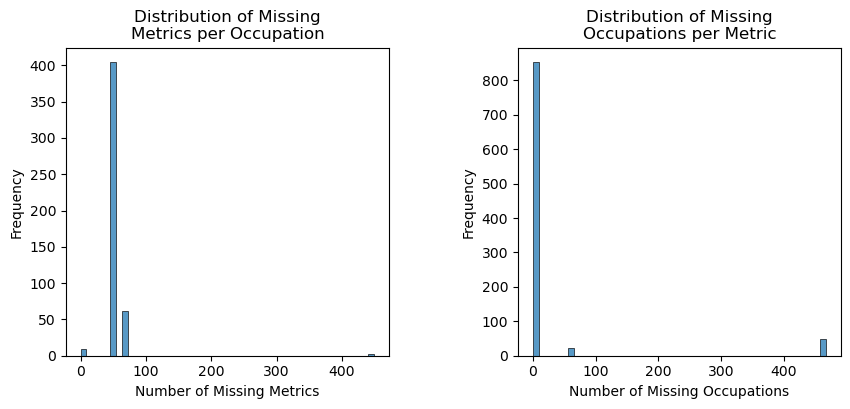

In [11]:
missing_values_hist_plot(df_pivoted, bins = 50)

Left Plot: shows the distribution of the number of missing metrics across different occupations. Each bar represents the frequency of occupations with a certain number of missing metrics. For example, the tall bar at x=50 means many occupations have 50 missing metrics.

Right Plot: shows the distribution of the number of missing occupations across different metrics. Each bar represents the frequency of metrics with a certain number of missing occupations. For example, the tall bar at x=0 means many metrics have 0 occupations with missing data, which is good news for us.

Recall our aim is to first remove problematic metrics that do not appear in many of our occupations. In our left plot we have a small group of metrics that are issing from approximately 450 of our occupations (the right most very small bar on the left hand plot). Lets use our dropna function with a threshold of 400 to remove these problematic metrics and then re-evaluate:

Notes: the axis = 1 op removes bars to the right of threshold value of left plot by dropping cols (metrics), axis = 0 op removes bars to the right of threshold on right plot by dropping rows (occupations)

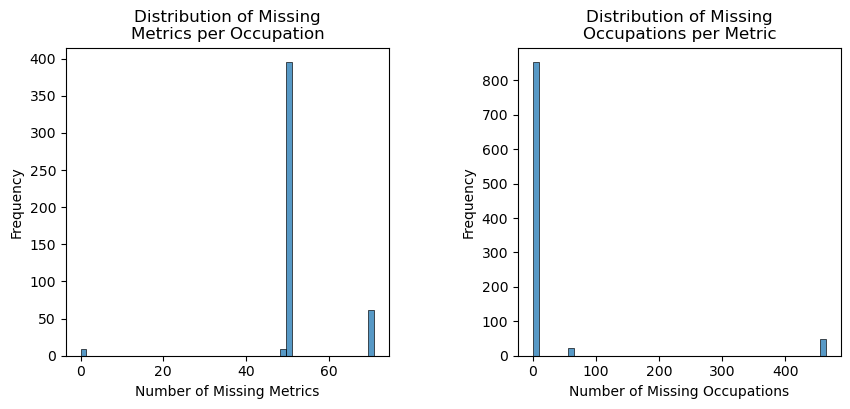

In [12]:
df_cleaned1 = drop_missing_values(df_pivoted, axis = 1, min_missing_values = 400)

# replot dist
missing_values_hist_plot(df_cleaned1, bins = 50)

It seems we have a group of occupations, as represented by the right most bar of the right hand plot, that are missing a large proportion of their metrics. Elect to remove these occupations as they provide little data by which to analyze them and alternatively removing the missing metrics would greatly reduce our feature space:

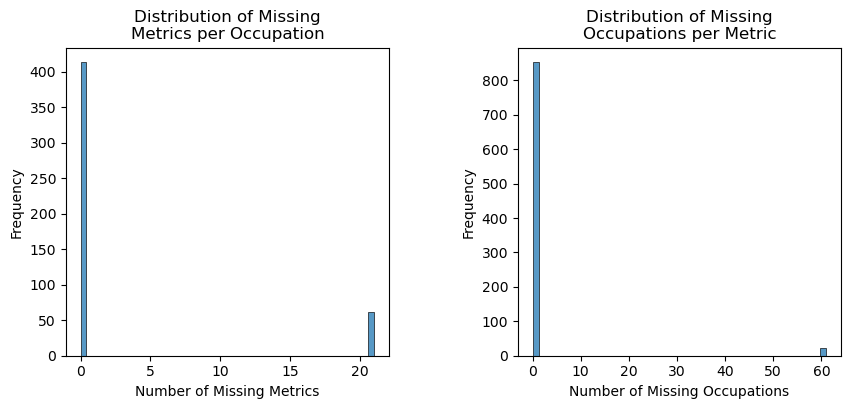

In [13]:
df_cleaned2 = drop_missing_values(df_cleaned1, axis = 0, min_missing_values = 400)

# replot dist
missing_values_hist_plot(df_cleaned2, bins = 50)

We now have a choice:
based on left plot: elect to remove approx 60 metrics that are missing from just over 20 occupations
or, 
based on right plot: elect to remove just over occupations that are missing about 60 metrics

As per our cleaning goal, we are aiming to keep as many occupations as possible whilst maintaining a large enough vector space for the similarity analysis to be of use. We still have just over 400 metrics which is more than enough and can accommodate losing 60 of them in order to keep ~20 more occupations. Elect to drop metrics:

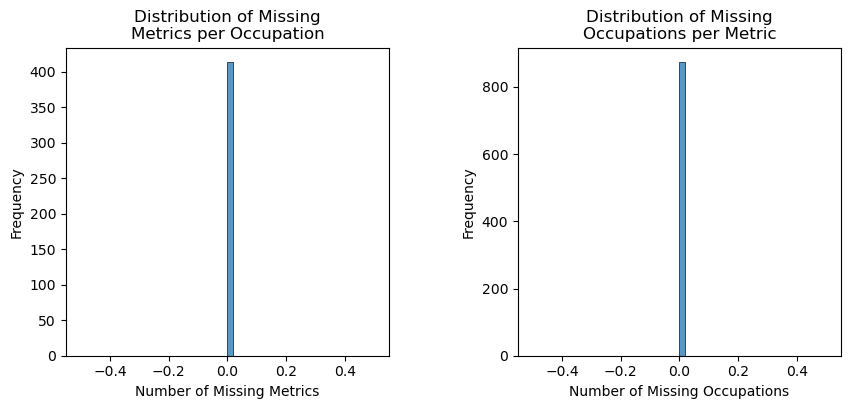

In [14]:
df_cleaned3 = drop_missing_values(df_cleaned2, axis = 1, min_missing_values = 20)
# replot dist
missing_values_hist_plot(df_cleaned3, bins = 50)

Great! we've removed all null values whilst being concious of the relative effects on both occupations and their feature space, lets do some quick checks to make sure everything is clean:

In [15]:
df_cleaned3.isna().sum().sum()

0

In [16]:
df_cleaned3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 873 entries, 11-1011.00 to 53-7121.00
Columns: 413 entries, ('Data Value', '1.A.1.a.1', 'IM') to ('Data Value', '4.C.3.d.8', 'CT')
dtypes: float64(413)
memory usage: 2.8+ MB


In [17]:
print(f'So we have a resultant dataframe containing df_cleaned3.shape[0] occupations measured via df_cleaned3.shape[1] metrics, electing to remove {round((df_pivoted.shape[0] - df_cleaned3.shape[0])/df_pivoted.shape[0] * 100, 1)}% of our occupations')

So we have a resultant dataframe containing df_cleaned3.shape[0] occupations measured via df_cleaned3.shape[1] metrics, electing to remove 5.4% of our occupations


## Modeling Skeleton for Web App

### Similarity Analysis

The user will select some key skills. interests etc and be used to find a starting point for their exploration. The best matched occupation based on the inputs will become the initial center of the plot.

Plan:
1. Represent the user's inputs as a binary vector where each element corresponds to a metric or feature in the dataset. Set the value to 1 for selected skills, interests etc, and 0 for non-selected attributes.

2. Calculate the similarity between the user's input vector and each row in the dataset using cosine similarity. Note although our Robust Scaler is not bounded, cosine similarity is concerned with direction only so a binary user vector is ok.

3. Return the top-ranked row as the best match

In [18]:
user_input = np.zeros(df_cleaned3.shape[1])
user_input[range(1, df_cleaned3.shape[1], 50)] = 1
np.where(user_input == 1)

(array([  1,  51, 101, 151, 201, 251, 301, 351, 401], dtype=int64),)

In [19]:
# reshape use_input to be 2d to match our df
user_input_reshaped = user_input.reshape(1, -1)
user_input_reshaped.shape

(1, 413)

In [20]:
similarities = cosine_similarity(user_input_reshaped, df_cleaned3)
similarities.shape

(1, 873)

In [21]:
# return index of best match
best_match_id = np.argmax(similarities)
best_match_id

386

Lets bring in our occupation dataset to add some context to this data point (note this will not need to be done for our web application, only need to join titles and center point description to plot data):

In [29]:
occupation_data = pd.read_excel('db_28_2_excel/Occupation Data.xlsx')
occupation_data.set_index('O*NET-SOC Code', inplace = True) # set code as index to match pca_df to make merging easier
occupation_data.head()

,Title,Description
O*NET-SOC Code,,
11-1011.00,Chief Executives,Determine and formulate policies and provide o...
11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."
11-1021.00,General and Operations Managers,"Plan, direct, or coordinate the operations of ..."
11-1031.00,Legislators,"Develop, introduce, or enact laws and statutes..."
11-2011.00,Advertising and Promotions Managers,"Plan, direct, or coordinate advertising polici..."


Our best match becomes:

In [40]:
print(f"Title: {occupation_data.loc[df_cleaned3.iloc[best_match_id].name, 'Title']}\nDescription: {occupation_data.loc[df_cleaned3.iloc[best_match_id].name, 'Description']}")

Title: Obstetricians and Gynecologists
Description: Provide medical care related to pregnancy or childbirth. Diagnose, treat, and help prevent diseases of women, particularly those affecting the reproductive system. May also provide general care to women. May perform both medical and gynecological surgery functions.


Now we have our most similar occupation to use as our ceter point for our plot, next we need to create the surrounding 2D plot.

### Apply Filtering

- Option 1: Pick n closest matches based on similarity and apply PCA to those points
- Option 2: Apply KNN to find n closest points by distance in n-dimensional space and apply PCA to those points

In [53]:
n = 30 # arbitrary number points to put on plot

# Option 1:
most_similar = np.argsort(similarities)[:, :n] # note similarties is 2D vector, need double indexing
most_similar

array([[772, 763, 732, 743, 740, 825, 349, 642, 820, 641, 490, 480, 758,
        781, 766, 723, 492, 654, 724, 694, 625, 664, 644, 628, 860, 704,
        863, 485, 105, 594]], dtype=int64)

In [59]:
# Option 2:
knn = NearestNeighbors(n_neighbors = n)
knn.fit(df_cleaned3)
distances, indices = knn.kneighbors(user_input_reshaped)
indices

C:\Users\Jason\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(


array([[539, 505, 512, 599, 594, 764, 473, 798, 763, 490, 467, 809, 625,
        502, 513, 871, 579, 732, 762, 644, 486, 856, 499, 546, 578, 480,
        765, 503, 544, 489]], dtype=int64)

In [73]:
print(f"We appear to get quite different answers depending on which method with only {len(np.intersect1d(most_similar, indices))} out of {n} common occupations between the two")

We appear to get quite different answers depending on which method with only 7 out of 30 common occupations between the two


In [65]:
# apply filtering:
#most_similar_data = df_cleaned3.iloc[most_similar.flatten()]
most_similar_data = df_cleaned3.iloc[indices.flatten()]

### Dimensionality Reduction

First lets scale our numeric data. Choose robust scaler to reduce the effect that outliers may have on our PCA vectors:

In [66]:
# scale
scaler = RobustScaler()
scaled_data = scaler.fit_transform(most_similar_data)

C:\Users\Jason\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(
C:\Users\Jason\anaconda3\lib\site-packages\sklearn\utils\validation.py:1688: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['tuple']. An error will be raised in 1.2.
  warnings.warn(


Next apply PCA to condense our dataframe down to to variables (to become our x and y axes for our plot):

In [69]:
# dimensionality reduction
pca = PCA(n_components = 2)
reduced_data = pca.fit_transform(scaled_data)

# convert back to dataframe
pca_df = pd.DataFrame(data = reduced_data, columns = ['PCA_1', 'PCA_2'])

pca_df.head()

,PCA_1,PCA_2
0,-4.476397,-2.059504
1,-11.538879,12.872004
2,-9.238379,12.167947
3,0.459429,-5.500026
4,2.184660,-6.951589


In [71]:
# Re-establish code indexesin our pca dataframe
pca_df.index = most_similar_data.index

# join df's based on codes
pca_df = pca_df.join(occupation_data)
pca_df.head()

,PCA_1,PCA_2,Title,Description
O*NET-SOC Code,,,,
51-6064.00,-4.476397,-2.059504,"Textile Winding, Twisting, and Drawing Out Mac...","Set up, operate, or tend machines that wind or..."
51-6021.00,-11.538879,12.872004,"Pressers, Textile, Garment, and Related Materials",Press or shape articles by hand or machine.
51-3023.00,-9.238379,12.167947,Slaughterers and Meat Packers,Perform nonroutine or precision functions invo...
51-4035.00,0.459429,-5.500026,"Milling and Planing Machine Setters, Operators...","Set up, operate, or tend milling or planing ma..."
51-4032.00,2.184660,-6.951589,"Drilling and Boring Machine Tool Setters, Oper...","Set up, operate, or tend drilling machines to ..."


Add in our user input best match at origin:

In [105]:
origin_row = occupation_data.loc[df_cleaned3.iloc[best_match_id].name]

origin_row

Title                            Obstetricians and Gynecologists
Description    Provide medical care related to pregnancy or c...
Name: 29-1218.00, dtype: object

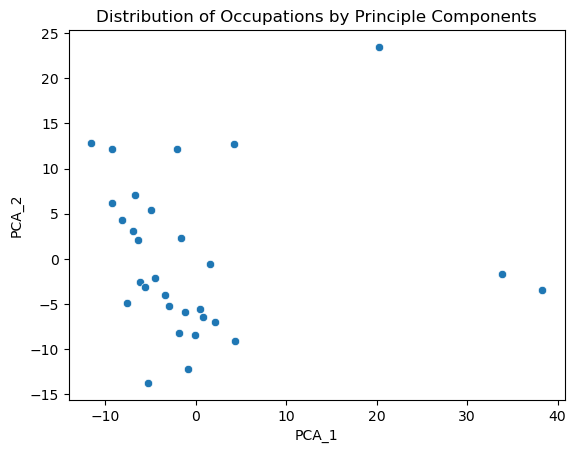

In [68]:
sns.scatterplot(data = pca_df, x = 'PCA_1', y = 'PCA_2')
plt.title('Distribution of Occupations by Principle Components')
plt.show()

Need to add in our user input best match (will be at origin).